# PyTorch's Hidden Memory Profiler: From Setup to Visual Insights

This notebook builds a small, reproducible project that demonstrates how to track memory allocations with PyTorch's built-in profiler and how to visualize the impact of a subtle memory leak using live OS metrics.

## Why Memory Profiling Matters
- Quantify where layers allocate memory without leaving the PyTorch stack
- Compare clean and bug-prone training loops under identical inputs
- Turn profiler stats and OS-level telemetry into visuals that tell the story

## 1. Setup – Imports and Environment Check
We start by importing PyTorch, the profiler utilities, and a few helper libraries for OS telemetry (`psutil`), data manipulation (`pandas`), and plotting (`matplotlib`). The output confirms the versions and which device (CPU or GPU) we are executing on.

In [1]:
import os
import psutil
import torch
from torch import nn
from torch.profiler import profile, record_function, ProfilerActivity

import pandas as pd
import matplotlib.pyplot as plt

print(f'torch version: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

PROCESS = psutil.Process(os.getpid())

torch version: 2.8.0
CUDA available: False
Using device: cpu


## 2. Define a Synthetic Regression Workload
A compact multilayer perceptron gives us enough operations to profile without being slow. The helper functions build fresh training components and sample random regression batches directly on the target device.

In [2]:
torch.manual_seed(7)
input_features = 256
hidden_units = 512
batch_size = 512

class TinyRegressor(nn.Module):
    def __init__(self, in_features: int, hidden_features: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, hidden_features),
            nn.ReLU(),
            nn.Linear(hidden_features, hidden_features),
            nn.ReLU(),
            nn.Linear(hidden_features, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

def generate_batch(current_batch_size: int = batch_size):
    features = torch.randn(current_batch_size, input_features, device=device)
    targets = torch.randn(current_batch_size, 1, device=device)
    return features, targets

def init_training_state():
    model = TinyRegressor(input_features, hidden_units).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.MSELoss()
    return model, optimizer, criterion

model, optimizer, criterion = init_training_state()
sample_x, sample_y = generate_batch(4)
print(f'Sample input shape: {sample_x.shape}')
print(f'Sample target shape: {sample_y.shape}')

Sample input shape: torch.Size([4, 256])
Sample target shape: torch.Size([4, 1])


## 3. Sanity-Check the Training Loop
We run a single optimization step to make sure gradients flow and the loss decreases from a valid scalar. This prevents chasing profiler issues that are really setup bugs.

In [3]:
model.train()
features, targets = generate_batch()
optimizer.zero_grad()
outputs = model(features)
loss = criterion(outputs, targets)
loss.backward()
optimizer.step()
print(f'Warm-up loss: {loss.item():.4f}')

Warm-up loss: 0.9696


## 4. Profiling Helper with Optional Activation Cache
The `profile_training` function rebuilds the model, runs several batches under `torch.profiler.profile`, and captures two streams of telemetry:

1. PyTorch operator-level stats (including per-op memory allocations).
2. Process-wide RSS (resident set size) before and after each step via `psutil`.

When `cache_activations=True`, the function purposely stores detached predictions to simulate a debugging pattern that grows memory usage across steps.

In [4]:
def profile_training(cache_activations: bool = False, steps: int = 6):
    torch.manual_seed(7)  # keep inputs identical between runs
    model, optimizer, criterion = init_training_state()
    activation_cache = []
    memory_trace = []
    activities = [ProfilerActivity.CPU]

    with profile(
        activities=activities,
        record_shapes=True,
        profile_memory=True,
        with_stack=True,
    ) as prof:
        for step_idx in range(steps):
            rss_before = PROCESS.memory_info().rss
            batch_x, batch_y = generate_batch()
            optimizer.zero_grad(set_to_none=True)

            with record_function('forward'):
                predictions = model(batch_x)
                loss = criterion(predictions, batch_y)

            with record_function('backward'):
                loss.backward()

            with record_function('optimizer_step'):
                optimizer.step()

            rss_after = PROCESS.memory_info().rss
            memory_trace.append({
                'step': step_idx + 1,
                'rss_mb_before': rss_before / (1024 ** 2),
                'rss_mb_after': rss_after / (1024 ** 2),
                'cache_enabled': cache_activations,
            })

            if cache_activations:
                activation_cache.append(predictions.detach().cpu())

    return prof, activation_cache, memory_trace

## 5. Baseline Profile (No Activation Cache)
We profile six training steps without caching anything extra. The table highlights the heaviest CPU memory consumers, while `summarize_memory` converts the profiler output into a lightweight list for later comparisons.

In [5]:
def summarize_memory(prof, limit: int = 8):
    summary_rows = []
    for evt in prof.key_averages():
        mem_bytes = evt.self_cpu_memory_usage
        if mem_bytes == 0:
            continue
        summary_rows.append({
            'name': evt.key,
            'calls': evt.count,
            'self_mem_mb': mem_bytes / (1024 ** 2),
            'cpu_time_ms': evt.self_cpu_time_total / 1000.0,
        })
    summary_rows.sort(key=lambda row: row['self_mem_mb'], reverse=True)
    return summary_rows[:limit]

baseline_prof, baseline_cache, baseline_mem = profile_training(cache_activations=False, steps=6)
print(baseline_prof.key_averages().table(sort_by='self_cpu_memory_usage', row_limit=12))

baseline_summary = summarize_memory(baseline_prof)
for row in baseline_summary:
    print(f"{row['name']:>30s} | calls: {row['calls']:2d} | self memory MB: {row['self_mem_mb']:.3f} | self CPU time ms: {row['cpu_time_ms']:.2f}")

-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg       CPU Mem  Self CPU Mem    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                               aten::mm        15.30%       2.791ms        15.31%       2.793ms      93.087us      21.01 MB      21.01 MB            30  
                                            aten::addmm        14.15%       2.581ms        15.24%       2.780ms     154.439us      12.01 MB      12.01 MB            18  
                                        aten::clamp_min         1.43%     260.293us         1.43%     260.293us      21.691us      12.00 MB      12.00

## 6. Simulate a Memory Leak by Caching Activations
Repeating the same run while storing predictions illustrates how a seemingly harmless debug aid can dominate allocations. We measure the total cached tensor size and capture the new profiler summary for comparison.

In [6]:
cached_prof, activation_cache, cached_mem = profile_training(cache_activations=True, steps=6)
cache_bytes = sum(t.element_size() * t.nelement() for t in activation_cache)
print(f'Cached tensors: {len(activation_cache)} batches')
print(f'Total cached size: {cache_bytes / (1024 ** 2):.3f} MB')
print(cached_prof.key_averages().table(sort_by='self_cpu_memory_usage', row_limit=12))

cached_summary = summarize_memory(cached_prof)
print()
print('Top memory ops with caching enabled:')
for row in cached_summary:
    print(f"{row['name']:>30s} | calls: {row['calls']:2d} | self memory MB: {row['self_mem_mb']:.3f} | self CPU time ms: {row['cpu_time_ms']:.2f}")

# Release cached tensors to avoid holding onto memory beyond this cell
activation_cache.clear()
del activation_cache

Cached tensors: 6 batches
Total cached size: 0.012 MB


-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg       CPU Mem  Self CPU Mem    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                               aten::mm        17.71%       2.862ms        17.72%       2.864ms      95.463us      21.01 MB      21.01 MB            30  
                                            aten::addmm        13.63%       2.202ms        15.03%       2.430ms     134.972us      12.01 MB      12.01 MB            18  
                                        aten::clamp_min         1.93%     311.798us         1.93%     311.798us      25.983us      12.00 MB      12.00


Top memory ops with caching enabled:
                      aten::mm | calls: 30 | self memory MB: 21.012 | self CPU time ms: 2.86
                   aten::addmm | calls: 18 | self memory MB: 12.012 | self CPU time ms: 2.20
               aten::clamp_min | calls: 12 | self memory MB: 12.000 | self CPU time ms: 0.31
      aten::threshold_backward | calls: 12 | self memory MB: 12.000 | self CPU time ms: 0.40
                    aten::sqrt | calls: 36 | self memory MB: 9.035 | self CPU time ms: 0.27
                     aten::div | calls: 36 | self memory MB: 9.035 | self CPU time ms: 0.26
                   aten::empty | calls: 30 | self memory MB: 2.533 | self CPU time ms: 0.02
           aten::empty_strided | calls: 168 | self memory MB: 2.512 | self CPU time ms: 0.05


## 7. Visualize RSS Growth with OS Telemetry
Using the `psutil` traces captured during profiling, we build a tidy DataFrame and plot the resident memory after each step. The visual makes it clear how caching activations causes a monotonic climb compared to the steady baseline.

In [7]:
telemetry_df = pd.concat([
    pd.DataFrame(baseline_mem),
    pd.DataFrame(cached_mem),
], ignore_index=True)
telemetry_df['mode'] = telemetry_df['cache_enabled'].map({False: 'baseline', True: 'cached'})
telemetry_df = telemetry_df.drop(columns=['cache_enabled'])
telemetry_df

,step,rss_mb_before,rss_mb_after,mode
0,1,334.328125,340.890625,baseline
1,2,340.890625,342.046875,baseline
2,3,342.046875,342.171875,baseline
3,4,342.171875,342.281250,baseline
4,5,342.281250,342.421875,baseline
5,6,342.421875,342.546875,baseline
6,1,359.359375,361.890625,cached
7,2,361.890625,362.171875,cached
8,3,362.171875,362.187500,cached
9,4,362.187500,362.218750,cached


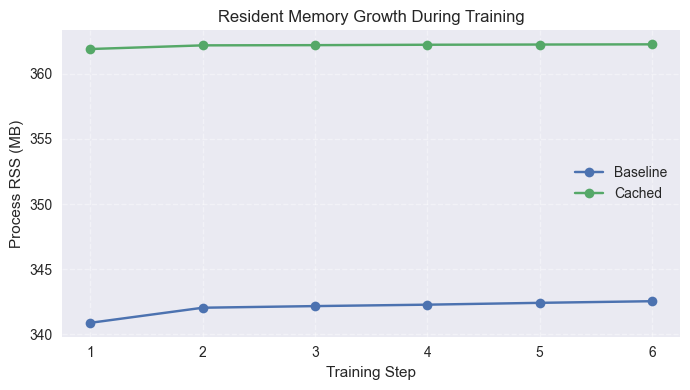

In [8]:
plt.style.use('seaborn-v0_8')
fig, ax = plt.subplots(figsize=(7, 4))
for mode, group in telemetry_df.groupby('mode'):
    ax.plot(group['step'], group['rss_mb_after'], marker='o', label=mode.title())

ax.set_xlabel('Training Step')
ax.set_ylabel('Process RSS (MB)')
ax.set_title('Resident Memory Growth During Training')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

## 8. Compare Profiler Summaries Side by Side
This helper prints the delta in per-operator memory allocations between baseline and cached runs so you can pinpoint which operations reacted to the leak.

In [9]:
def compare_memory(baseline_rows, cached_rows):
    baseline_map = {row['name']: row for row in baseline_rows}
    cached_map = {row['name']: row for row in cached_rows}
    op_names = sorted(set(baseline_map) | set(cached_map))
    for name in op_names:
        base_mb = baseline_map.get(name, {'self_mem_mb': 0.0})['self_mem_mb']
        cached_mb = cached_map.get(name, {'self_mem_mb': 0.0})['self_mem_mb']
        delta = cached_mb - base_mb
        if abs(delta) < 1e-6:
            continue
        print(f"{name:>30s} | baseline MB: {base_mb:6.3f} -> cached MB: {cached_mb:6.3f} | delta: {delta:6.3f}")

compare_memory(baseline_summary, cached_summary)

                     aten::div | baseline MB:  9.035 -> cached MB:  9.035 | delta: -0.000
                   aten::empty | baseline MB:  3.033 -> cached MB:  2.533 | delta: -0.500
           aten::empty_strided | baseline MB:  3.010 -> cached MB:  2.512 | delta: -0.498


## Key Takeaways
- PyTorch's native profiler already exposes per-operator memory usage; no external instrumentation was needed.
- Combining profiler stats with OS-level RSS readings paints a fuller picture of memory growth over time.
- Small diagnostics (like caching activations) can quietly accumulate tens of megabytes—profiling both the clean and debugged paths quantifies the cost immediately.
- Exporting `cached_prof.export_chrome_trace('cached_run.json')` is an easy next step if you want a timeline view in Chrome's tracing tools.